In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import numpy as np
import pyccl as ccl
import pandas as pd
import pylab as plt

<h3> I define the global configuration </h3>

In [3]:
config_global = dict(
                    H0 = 68.1,
                    Om_m = 0.306, # Omega matter
                    Om_b = 0.0486, # Omega baryons
                    sigma8 = 0.807,
                    n_s = 0.967,
                    num_k = 10001,
                    rp_model_min = 7.391, # Minimum transverse distance to model in Mpc
                    rp_model_max = 128.016, # Maximum transverse distance to model in Mpc
                    bins_rp_model = 16, # Number of transverse distance bins
                    log10kmin = -5, # minimum k
                    log10kmax = 2, # maximum k
                    l_min = 0, # Minimum l
                    l_max = 10001, # Maximum l
                    steps_l = 10, # Steps in l
                    IA_model = 'TATT', # Model for IA
                    )

<h3> I update the config setup </h3>

In [4]:
from IATheory.process_config import init_cosmology, init_grids, init_pt_calculators, compute_kernels_spec, init_lightcone, init_photometric, update_global_config, build_specific_config

In [5]:
# We need to perform some initial computations from the global configuration. This includes definining the CCL cosmo library, define k and rp arrays and initialise PT calculators.
config_global = update_global_config(config_global)

<h3> Initialise the modelling class </h3>

In [6]:
from IATheory.compute_observables import model_2p_corr

In [7]:
galaxy_bias = [1.2, -0.4]
ia_params = [0.5, 1, 1.5]
model = model_2p_corr(config_global, galaxy_bias, ia_params)
print(model.__doc__)


    This class computes projected galaxy-galaxy (wgg) and galaxy-shear (wg+) correlation functions.
    It also allows to compute these observables in a lightcone and in a box.
    In the case of a lightcone, it can model spectroscopic and photometric redshifts cases.

    Arguments:
    -----------
        galaxy_bias (nunmpy array): Galaxy bias values
        ia_params (nunmpy array): Intrinsic alignment values

    Attributes:
    -----------
        config (dict): Configuration dictionary for the computation.
        wgg_spec_box (object, optional): Projected galaxy-galaxy (position-position) correlation function with spectroscopic redshifts in a box.
        wgg_spec_lightcone (object, optional): Projected galaxy-galaxy (position-position) correlation function with spectroscopic redshifts in a lightcone.
        wgg_phot_lightcone (object, optional): Projected galaxy-galaxy (position-position) correlation function with photometric redshifts in a lightcone.
        wgp_spec_box (o

<h3> Define plotting function </h3>

In [8]:
def plot_wgg_wgp(rp_model, wgg, wgp):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (10, 5))
    ax1.plot(rp_model, wgg)
    ax1.set_xlabel(r'$r_{p}$ [Mpc]', fontsize = 14)
    ax1.set_ylabel(r'$w_{gg}$ [Mpc]', fontsize = 14)

    ax2.plot(rp_model, wgp)
    ax2.set_xlabel(r'$r_{p}$ [Mpc]', fontsize = 14)
    ax2.set_ylabel(r'$w_{gp}$ [Mpc]', fontsize = 14)
    plt.tight_layout()
    plt.show()

<h2> Cases using the box </h2>

<h3> Compute galaxy clustering (wgg) and intrinsic alignments (wgp) </h3>

In [9]:
case = 'box'
config_setup_box = dict(z_box=0) #redshift of the box
config_box = build_specific_config(config_global, config_setup_box, case)

In [10]:
model.model_wgg_spec_box(config_box)
model.model_wgp_spec_box(config_box)

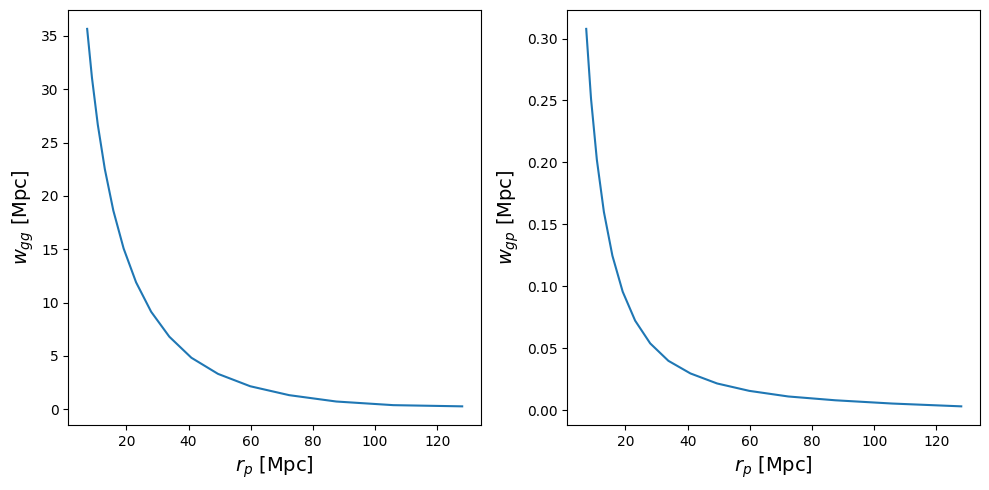

In [11]:
plot_wgg_wgp(config_global['rp_model'], model.wgg_spec_box.xi, model.wgp_spec_box.xi)

<h2> Cases using the lightcone </h2>

<h3> Spec-z </h3>

In [12]:
# Execute this cell to download the data
data_downloaded = True

if data_downloaded == False:
    
    import requests
    
    # URLs of the files to be downloaded
    urls = {
        'positions_nz.csv': 'https://zenodo.org/records/15092862/files/nz_example.fits',
        'shapes_nz.csv': 'https://zenodo.org/records/17191365/files/example-mixmats.fits'
    }
    
    # Function to download a file
    def download_file(url, filename):
        response = requests.get(url)
        if response.status_code == 200:
            with open(filename, 'wb') as f:
                f.write(response.content)
            print(f'{filename} downloaded successfully')
        else:
            print(f'Failed to download {filename}. Status code: {response.status_code}')
    
    # Download all files
    for filename, url in urls.items():
        download_file(url, filename)

In [13]:
case = 'lightcone_spec'
path_nz_positions = '/nfs/pic.es/user/d/dnavarro/IATheory/data/nz/positions_nz.csv'
path_nz_shapes = '/nfs/pic.es/user/d/dnavarro/IATheory/data/nz/shapes_nz.csv'
config_setup_lightcone_spec = dict(z_min = 0., # Minimum redshift to model
                                   z_max = 1.1, # Maximum redshift to model
                                   z_type = 'spec', # It can either be "phot" or "spec"
                                   path_nz_positions = path_nz_positions, # nz for the positions in csv format
                                   path_nz_shapes = path_nz_shapes # nz for the shapes in csv format
                                  )
config_lightcone_spec = build_specific_config(config_global, config_setup_lightcone_spec, case)

In [14]:
model.model_wgg_spec_lightcone(config_lightcone_spec)
model.model_wgp_spec_lightcone(config_lightcone_spec)

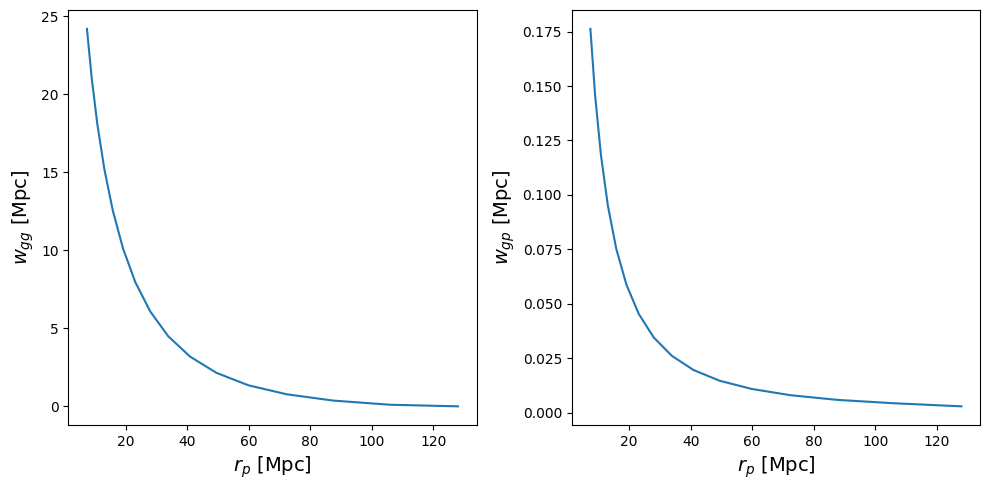

In [15]:
plot_wgg_wgp(config_global['rp_model'], model.wgg_spec_lightcone.xi, model.wgp_spec_lightcone.xi)

<h3> Photo-z </h3>

In [16]:
case = 'lightcone_phot'
path_nz_positions = '/nfs/pic.es/user/d/dnavarro/IATheory/data/nz/positions_nz.csv'
path_nz_shapes = '/nfs/pic.es/user/d/dnavarro/IATheory/data/nz/shapes_nz.csv'
config_setup_lightcone_phot = dict(z_min = 0., # Minimum redshift to model
                                   z_max = 1.1, # Maximum redshift to model
                                   z_type = 'phot', # It can either be "phot" or "spec"
                                   path_nz_positions = path_nz_positions, # nz for the positions in csv format
                                   path_nz_shapes = path_nz_shapes, # nz for the shapes in csv format
                                   Pi = np.array([-233,-144,-89,-55,-34,-21,-13,-8,-5,-3,-2,-1,0,1,2,3,5,8,13,21,34,55,89,144,233])/(config_global['H0']/100), # Pi binning (in Mpc)
                                   bins_zm = 10, # Number of redshift bins for the error distribution in the phot case
                                   add_magnification = True, # This boolean is used in the case of correlation functions with photometric redshifts to indicate whether to include magnification as a contaminant or not.
                                   alpha_magnification = 0.93, # Value of the magnification alpha. Only needed in cases add_magnification = True
                                   add_galaxy_galaxy_lensing = True, # This boolean is used in the case of correlation functions with photometric redshifts to indicate whether to include magnification as a contaminant or not.
                                   )
config_lightcone_phot = build_specific_config(config_global, config_setup_lightcone_phot, case)

In [16]:
model.model_wgg_phot_lightcone(config_lightcone_phot)
model.model_wgp_phot_lightcone(config_lightcone_phot)

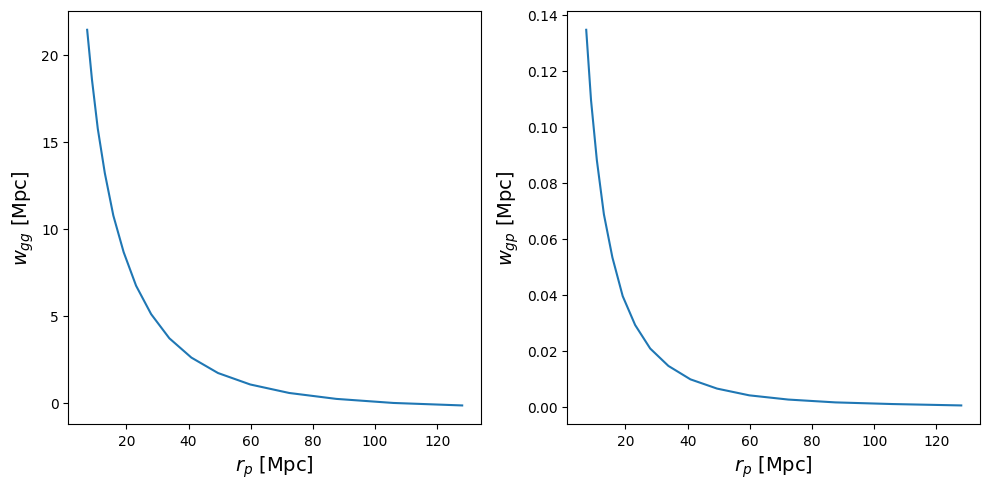

In [17]:
plot_wgg_wgp(config_global['rp_model'], model.wgg_phot_lightcone.xi, model.wgp_phot_lightcone.xi)